# Use the structure of genZWPusingCylMaps.ipynb to create a staggered window approach. The use corr_1D (sliding window) result to generate profiles for every single image pair using the staggering technique.

# Staggering technique minimizes the difference at each latitude between the correlation and the yearly HST data.

In [1]:
import planetmapper
from planetmapper.kernel_downloader import download_urls
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from astropy.io import fits
import time
from scipy.signal import correlate
import scipy as sp
import pytz
import datetime
import csv
import os
import pandas as pd

# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class


In [2]:
# longitutde array is defined relative to the West, which is how all maps are projected for this project.
long_res, lat_res = 360, 180
long_res_hi, lat_res_hi = 720, 360
long_array, lat_array = np.linspace(360, 0,long_res), np.linspace(-90, 90,lat_res)
long_array_hi, lat_array_hi = np.linspace(360, 0,long_res_hi), np.linspace(-90, 90,lat_res_hi)

one_J_day = 9.9258 # hours
variation = 51/60 # hrs
R_J = 71492e3 # m
R_J_p = 66854e3 # m

oblateness = (R_J - R_J_p) / R_J # Jupiter oblateness
print(oblateness)
print(2*np.pi*R_J, one_J_day*3600, (variation/one_J_day)*180/np.pi)

print(R_J*(1 - oblateness*np.sin(lat_array*np.pi/180)**2)[89])

0.0648743915403122
449197483.980883 35732.880000000005 4.9065478436115955
71491642.84783395


In [3]:
print('Maximum possible speed at a given latitude: ', R_J * (10/360) * 2*np.pi / (one_J_day * 3600))

Maximum possible speed at a given latitude:  349.1940165012688


In [4]:
'''
Load data from file to get the correct file list
'''

# Update if need be but try to keep things where they are. execution_path is the directory in which /prvt/ exists.
execution_path = '/Users/ahyder/Desktop/windfieldproject'

# Load from a CSV file
year = "2024"
main_path = 'spex/post_invigilation/'
cmap_files_paths_list_51 = [] # with threshold set to 51 min (0.85)
t_diff_list_cmap_51 = []

with open(main_path+f"PI_{year}.csv", "r") as f:
    reader = csv.reader(f)
    counter = 0
    for row in reader:
        selected_pair, t_diff_of_pair = [row[0], row[1]], float(row[2])
        t_diff_list_cmap_51.append(t_diff_of_pair)
        cmap_files_paths_list_51.append([selected_pair[0], selected_pair[1]])
        print(counter, selected_pair, t_diff_of_pair)
        counter += 1


'''
Super important index list! It is necessary for compatiblity of the maps.
0 - pair is already compatible.
1 - first map has a higher resolution and needs to be unresolved.
2 - second map has a higher resolution and needs to be unresolved.
'''

date_meta_list = []
smart_index_list = np.zeros(len(cmap_files_paths_list_51))
for i_f, f in enumerate(cmap_files_paths_list_51):
    hdul0 = fits.open(execution_path+f[0])
    hdul1 = fits.open(execution_path+f[1])
    d_t_0 = str(hdul0[0].header['DATE_OBS'] + 'T' + hdul0[0].header['TIME_OBS'])
    d_t_1 = str(hdul1[0].header['DATE_OBS'] + 'T' + hdul1[0].header['TIME_OBS'])
    date_meta_list.append([d_t_0, d_t_1])
    print(f[0].split('spex/')[-1], f[1].split('spex/')[-1])
    smart_index_list[i_f] = ZWP_Class.checkMapResolution(hdul0[0].data, hdul1[0].data)
    hdul0.close()
    hdul1.close()

compatible_map_pairs = ZWP_Class.makeMapsCompatible(cmap_files_paths_list_51, smart_index_list, emission_angle_correction=True, execution_path_bool=True, fits_str='.mu.gz') # defaults to fits_str='.mu.fits.gz'

print(smart_index_list)
for i in range(len(compatible_map_pairs)):
    print(i, compatible_map_pairs[i][0].shape, compatible_map_pairs[i][1].shape, int(smart_index_list[i]), date_meta_list[i])

print()
print(f'Total of {len(smart_index_list)} pairs to work through...')


0 ['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz', '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz'] 18.919450955277778
1 ['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz', '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc329353.cmap.gz'] 20.205661894444443
2 ['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz', '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc148182.cmap.gz'] 19.373233508333332
3 ['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc523554.cmap.gz', '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz'] 20.52804470555556
4 ['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz', '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz'] 18.91849826388889
5 ['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz', '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc329353.cmap.gz'] 20.204709203055558
6 ['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.g

In [5]:
test_i             = 0    # index of the pair being correlated.
long_shift_applied = 90   # what is the shift that you want to apply, if need be.
margin_app         = 5    # how far you want to be from the NaNs. Sometimes needs to be lowered to 3 in the event that margin application fails.
window_length      = 45   # width of the sliding window.
window_stepping    = 1    # how many longitudes does the sliding take.
critical_lat       = 55   # the latitude where the correlation function stops applying.
std_stagger        = 1.15 # sigma threshold that defines how large the max peak can be beyond the median of a specific latitude.

# Rarely changed variables:
max_delta_longit   = 10   # how many ∆longitudes are permitted.
lat_res_tol        = 1e-2 # margin calculation threshold using critical latitude.
force_shift        = False

print(ZWP_Class.getSpeedatLat(max_delta_longit, lat_array, t_diff_list_cmap_51[test_i]*3600))

print('map shape: ', compatible_map_pairs[test_i][0].shape)
print()

if compatible_map_pairs[test_i][0].size > 180*360:
    lat_array_use  = lat_array_hi
    long_array_use = long_array_hi
else:
    lat_array_use  = lat_array
    long_array_use = long_array


_, _, _, _, _, corr_1D, corr_1D_coeff, error_array_slide, fwhm_array_slide, stagger_bool = ZWP_Class.getFullLatitudinalCorrelation(
                            compatible_map_pairs[test_i][0], compatible_map_pairs[test_i][1], 
                            long_array_use, lat_array_use, shift_long=long_shift_applied, crit_lat=critical_lat, 
                            margin=margin_app, max_delta_long=max_delta_longit, force_shift=force_shift, sliding_window_boolean=True, sliding_window_len=window_length, window_step=window_stepping, stagger=True, std_stagger=std_stagger, lat_res_tol=lat_res_tol)
print()
shifted_f1, shifted_f2, shifted_BIM, margin_applied_in_func_shifted, final_longitudes_masked_shifted, corr_1D_noshift, corr_1D_coeff_noshift, error_array, fwhm_array = ZWP_Class.getFullLatitudinalCorrelation(
                            compatible_map_pairs[test_i][0], compatible_map_pairs[test_i][1], 
                            long_array_use, lat_array_use, shift_long=long_shift_applied, crit_lat=critical_lat, 
                            margin=margin_app, max_delta_long=max_delta_longit, force_shift=force_shift, sliding_window_boolean=False, sliding_window_len=window_length, window_step=window_stepping, lat_res_tol=lat_res_tol)

# due to shift, the x-axis is technically wrapped so plotting the margins must be done with the appropriate wrapping commands:
# print(long_array[20]+90-360, long_array[232]+90)

# plt.contourf(long_array, lat_array, shifted_BIM)
# plt.gca().invert_xaxis()
# # plt.vlines(long_array[146], -90, 90), plt.vlines(long_array[286], -90, 90)
# # plt.colorbar()
# plt.show()

# print(final_longitudes_masked_shifted)

[1.12177212e-14 3.21512846e+00 6.42926659e+00 9.64142436e+00
 1.28506124e+01 1.60558421e+01 1.92561262e+01 2.24504791e+01
 2.56379166e+01 2.88174572e+01 3.19881213e+01 3.51489323e+01
 3.82989167e+01 4.14371041e+01 4.45625280e+01 4.76742256e+01
 5.07712384e+01 5.38526126e+01 5.69173990e+01 5.99646535e+01
 6.29934376e+01 6.60028182e+01 6.89918685e+01 7.19596678e+01
 7.49053018e+01 7.78278633e+01 8.07264521e+01 8.36001753e+01
 8.64481478e+01 8.92694923e+01 9.20633398e+01 9.48288296e+01
 9.75651101e+01 1.00271338e+02 1.02946681e+02 1.05590313e+02
 1.08201421e+02 1.10779201e+02 1.13322859e+02 1.15831610e+02
 1.18304682e+02 1.20741314e+02 1.23140755e+02 1.25502266e+02
 1.27825120e+02 1.30108600e+02 1.32352004e+02 1.34554640e+02
 1.36715831e+02 1.38834910e+02 1.40911225e+02 1.42944136e+02
 1.44933017e+02 1.46877255e+02 1.48776252e+02 1.50629422e+02
 1.52436195e+02 1.54196015e+02 1.55908338e+02 1.57572638e+02
 1.59188403e+02 1.60755133e+02 1.62272348e+02 1.63739579e+02
 1.65156374e+02 1.665222

In [6]:
compatible_map_pairs[test_i][0].shape, corr_1D.shape

((360, 720), (360, 85))

In [7]:
'''
Load some HST data for comparison and get the appropriate ∆t for the case currently being used.
'''

hst_wind_1D = np.genfromtxt('Simon+2015_ZWP_HST.csv', delimiter=",", dtype=None, encoding=None, names=True)[:]
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')
delta_t = t_diff_list_cmap_51[test_i]*3600

# convert HST planetographic latitudes to planetocentric
centric_lat_HST = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, opal_nov_2024_df['LAT']))
centric_lat_HST_2015 = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, hst_wind_1D['y']))[:]


In [8]:
lat_delta_indices = [np.where(np.isclose(lat_array_use, -critical_lat, lat_res_tol))[0][0], np.where(np.isclose(lat_array_use, critical_lat, lat_res_tol))[0][0]+1]
print(lat_delta_indices)
# print('Smooth wind with all latitudes (no critcal_lat applied): ', smooth_wind_full.shape)
# print('Smooth wind output (limited to the critical range): ', smooth_wind_full[lat_delta_indices[0]:lat_delta_indices[1], :].shape)
print('Stagger output (limited to the critical range, as is the output of the main function): ', stagger_bool.shape)
# print(smooth_wind_full[lat_delta_indices[0]:lat_delta_indices[1], :] * stagger_bool[0, ...])

[np.int64(69), np.int64(290)]
Stagger output (limited to the critical range, as is the output of the main function):  (2, 221, 85)


(360,)
360
68110.023439


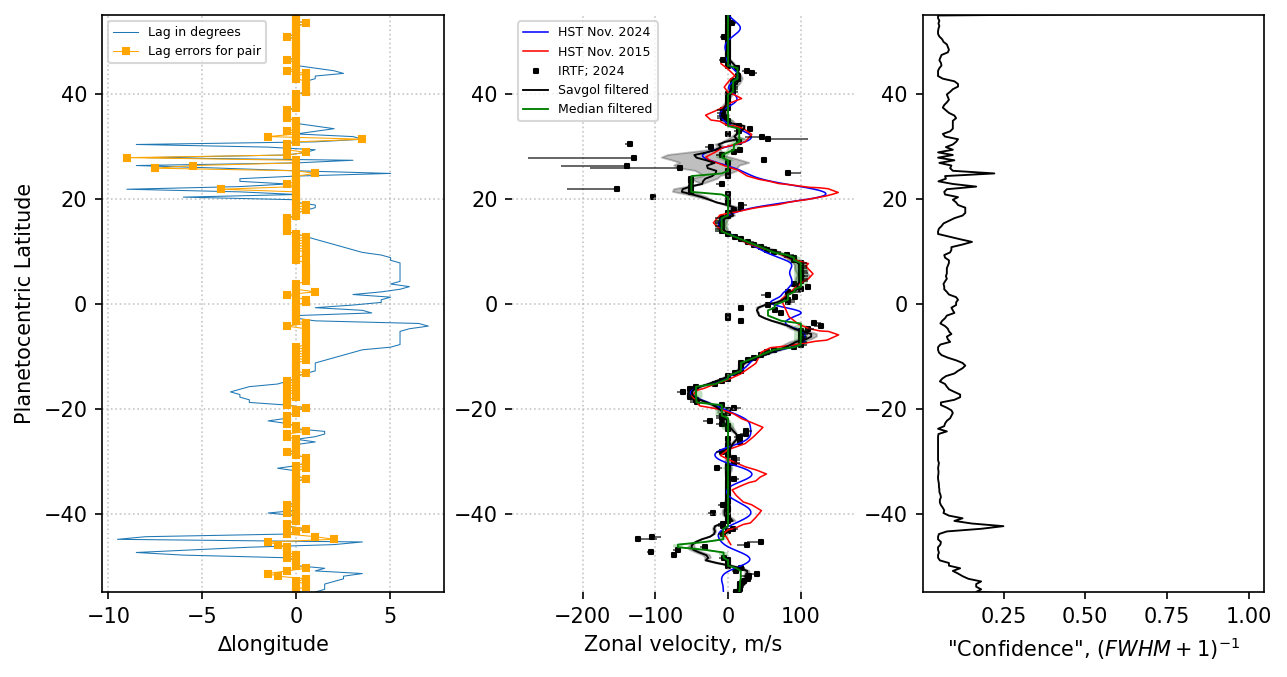

In [9]:
pearson_thresh = 0.275
corr_1D_with_thresh = corr_1D_noshift

print(corr_1D_noshift.shape)


'''
For fullCorrelation() - NO SLIDING WINDOW USED OR AN AVERAGING HAS BEEN PERFORMED...
'''
zwp_5microns = -ZWP_Class.getSpeedatLat(corr_1D_with_thresh, lat_array_use, delta_t) # minus is necessary to match the other observations of the wind speed.
err_velocity = -ZWP_Class.getSpeedatLat(error_array, lat_array_use, delta_t) # correlation error bound in m/s

%matplotlib inline
y_lim_range = critical_lat #critical_lat - critical_lat*0.05 # -5% for aesthetics...
plt.figure(figsize=(10,5), dpi=150)

print(len(lat_array_use))
# Apply Savgol filter
smooth_zwp_5microns = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array_use, jet_width=7, poly_order=3)
smooth_err_velocity = ZWP_Class.getSmoothedProfile(err_velocity, lat_array_use, jet_width=7, poly_order=3)
confidence = 1/(fwhm_array+1)

#Apply median filter
medfilt_zwp_5microns = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array_use, filter_type='median', jet_width=4, poly_order=3)
medfilt_err_velocity = ZWP_Class.getSmoothedProfile(err_velocity, lat_array_use, filter_type='median', jet_width=4, poly_order=3)

plt.subplot(131)
plt.plot(-corr_1D_noshift, lat_array_use, lw=0.5, label='Lag in degrees')
plt.plot(-error_array, lat_array_use, marker='s', ms=3, color='orange', lw=0.5, label='Lag errors for pair')
plt.xlabel('∆longitude')
plt.ylabel('Planetocentric Latitude')
# plt.xlim(-1000, 1000)
plt.ylim(-critical_lat, critical_lat)
plt.legend(loc='upper left', framealpha=0.75, fontsize=6)
plt.grid(True, 'both', ls=':', alpha=0.7)

print(delta_t)

# test_var_array = np.array([5., 7.])
# test_var_array = np.array([3, 5])
# print(test_var_array)

plt.subplot(132)
plt.plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.75, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.75, label='HST Nov. 2015')

for z in range(len(zwp_5microns)):
    plt.hlines(lat_array_use[z], min(zwp_5microns[z], zwp_5microns[z]+err_velocity[z]), max(zwp_5microns[z], zwp_5microns[z]+err_velocity[z]), colors='k', alpha=0.75, lw=0.75)
    # plt.hlines(lat_array_use[z], zwp_5microns[z]-err_velocity[z], zwp_5microns[z]+err_velocity[z], colors='k', alpha=0.75, lw=0.75)
plt.scatter(zwp_5microns, lat_array_use, marker='s', s=5, color='k', label='IRTF; '+str(year))

plt.fill_betweenx(lat_array_use, smooth_zwp_5microns-smooth_err_velocity, smooth_zwp_5microns+smooth_err_velocity, lat_array_use, color='k', lw=0.9, alpha=0.25)
plt.plot(smooth_zwp_5microns, lat_array_use, color='k', lw=0.9, label='Savgol filtered')
# plt.fill_betweenx(lat_array_use, zwp_5microns-err_velocity, zwp_5microns+err_velocity, lat_array_use, color='orange', lw=0.9, alpha=0.5)

plt.fill_betweenx(lat_array_use, medfilt_zwp_5microns-medfilt_err_velocity, medfilt_zwp_5microns+medfilt_err_velocity, lat_array_use, color='g', lw=0.1, alpha=0.25)
plt.plot(medfilt_zwp_5microns, lat_array_use, color='g', lw=0.9, label='Median filtered')

# for i in range(len(test_var_array)):
#     smooth_zwp_5microns_var = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array_use, jet_width=7, poly_order=test_var_array[i])
#     plt.plot(smooth_zwp_5microns_var, lat_array_use, lw=0.5, label='jet 7')
plt.xlabel('Zonal velocity, m/s')
# plt.xlim(-1000, 1000)
plt.ylim(-critical_lat, critical_lat)
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(loc='upper left', framealpha=0.75, fontsize=6)

plt.gca().set_frame_on(False)

plt.subplot(133)
plt.plot(confidence, lat_array_use, color='k', lw=0.9)
plt.xlabel(r'"Confidence", $(FWHM+1)^{-1}$')
plt.ylim(-critical_lat, critical_lat)
plt.show()

In [10]:
print(ZWP_Class.closestIndex2Lat(lat_array_use, -20))
print(ZWP_Class.closestIndex2Lat(lat_array_use, +20))

sigma_clip = 3
arcsec_jup = 30 # minimum apparent angular diameter for Jupiter
region_mean, region_std = ZWP_Class.getSubPixErr(error_array, long_array_use, lat_array_use, NS_bounding_lat=20.0, sigma_clip=sigma_clip)
regional_wind_err_bound = ZWP_Class.getWindErratSubPix(subpix_std=region_std, arcsec_jup=arcsec_jup, delta_t=delta_t, arcsec_per_pix_spex=0.12)

print(f'Actual wind error in the ±20˚ region post sigma clipping ({sigma_clip}σ) at {arcsec_jup}": ±', round(regional_wind_err_bound, 2), ' m/s')

(np.int64(140), np.float64(-19.80501392757661))
(np.int64(219), np.float64(19.805013927576596))
Mean and std of ∆x_pixels at the sub-pixel level post sigma clipping:  -0.2125 0.6836254456937658
Actual wind error in the ±20˚ region post sigma clipping (3σ) at 30": ± 5.74  m/s


(360, 85) (360, 85)
(360,) (360,)
85


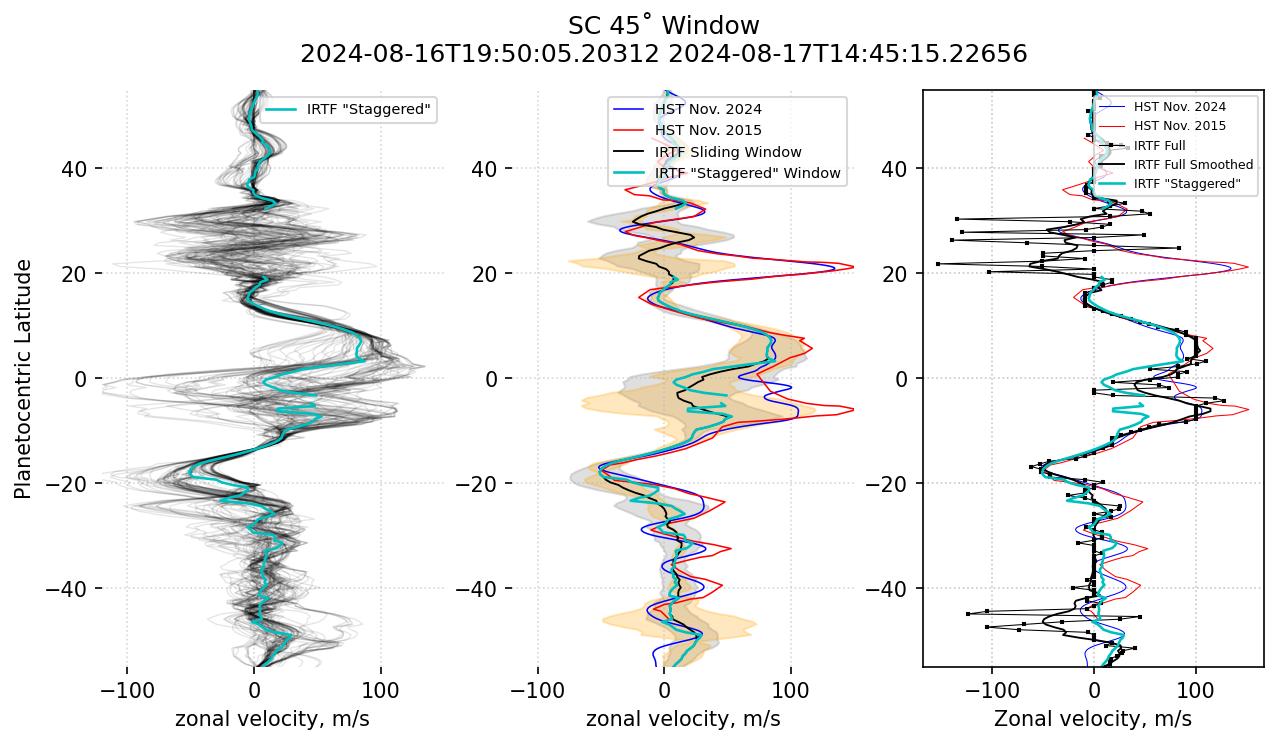

0.04993402319605172 0.4386184625746559


In [11]:
%matplotlib inline
print(corr_1D.shape, corr_1D_coeff.shape)
print(corr_1D_noshift.shape, corr_1D_coeff_noshift.shape)

def customWeightedAvg(main_mat, weight_mat):
    weighted_wind = np.zeros(main_mat.shape[0])
    for l in range(main_mat.shape[0]):
        if np.sum(weight_mat[l, :]) <= 1:
            weighted_wind[l] = np.nan
        else:
            weighted_wind[l] = np.sum(weight_mat[l, :] * main_mat[l, :]) / np.sum(weight_mat[l, :])
    return weighted_wind

smooth_wind_full = np.zeros_like(corr_1D)
rough_wind_full = np.zeros_like(corr_1D)

plt.figure(figsize=(10,5), dpi=150)
plt.subplot(131)
print(corr_1D.shape[1])
for c in range(corr_1D.shape[1]):
    rough_wind_full[:, c] = -ZWP_Class.getSpeedatLat(corr_1D[:, c], lat_array_use, delta_t)
    smooth_wind_full[:, c] = ZWP_Class.getSmoothedProfile(rough_wind_full[:, c], lat_array_use, jet_width=7, poly_order=3)
    plt.plot(smooth_wind_full[:, c], lat_array_use, color='k', lw=0.65, alpha=0.1)
    plt.ylim(-critical_lat, critical_lat)

weighted_wind = customWeightedAvg(smooth_wind_full[lat_delta_indices[0]:lat_delta_indices[1], :], stagger_bool[0, ...])
plt.plot(weighted_wind, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], color='c', lw=1.25, label='IRTF "Staggered"')

plt.ylabel('Planetocentric Latitude'), plt.xlabel('zonal velocity, m/s')
plt.gca().set_frame_on(False)
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.legend(loc='upper right', framealpha=0.75, fontsize=7)
plt.xlim(-120, 150)

# Either smooth before averaging or average before smoothing...
rough_wind_mean, rough_wind_std = np.mean(rough_wind_full, axis=1), np.std(rough_wind_full, axis=1)
smooth_wind_mean, smooth_wind_std = np.mean(smooth_wind_full, axis=1), np.std(smooth_wind_full, axis=1)
# smooth_wind_mean, smooth_wind_std = ZWP_Class.getSmoothedProfile(rough_wind_mean, lat_array_use, jet_width=7, poly_order=3), ZWP_Class.getSmoothedProfile(rough_wind_std, lat_array_use, jet_width=7, poly_order=3)


err_velocity_slide = -ZWP_Class.getSpeedatLat(error_array_slide, lat_array_use, delta_t) # correlation error bound for sliding window in m/s
smooth_err_velocity = ZWP_Class.getSmoothedProfile(err_velocity_slide, lat_array_use, jet_width=7, poly_order=3)
confidence_slide = 1/(fwhm_array_slide+1)


plt.subplot(132)
plt.plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.75, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.75, label='HST Nov. 2015')
plt.plot(smooth_wind_mean, lat_array_use, color='k', lw=0.9, label='IRTF Sliding Window')
plt.plot(weighted_wind, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], color='c', lw=1.25, label='IRTF "Staggered" Window')

# for c in range(corr_1D.shape[1]):
#     plt.plot(smooth_wind_full[lat_delta_indices[0]:lat_delta_indices[1], c] * stagger_bool[0, :, c] , lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], color='m', lw=0.65, alpha=0.1)

plt.fill_betweenx(lat_array_use, smooth_wind_mean-smooth_wind_std, smooth_wind_mean+smooth_wind_std, color='gray', alpha=0.25)
plt.fill_betweenx(lat_array_use, smooth_wind_mean-smooth_err_velocity, smooth_wind_mean+smooth_err_velocity, color='orange', alpha=0.25)
plt.ylim(-critical_lat, critical_lat)
plt.xlim(-120, 150)
plt.gca().set_frame_on(False)
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.xlabel('zonal velocity, m/s')
plt.legend(loc='upper right', framealpha=0.75, fontsize=7)
# plt.suptitle('Sliding Correlations with 45˚ Window')
plt.suptitle(f'SC {window_length}˚ Window\n'+date_meta_list[test_i][0] + ' ' + date_meta_list[test_i][1])


plt.subplot(133)
plt.plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.5, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.5, label='HST Nov. 2015')
plt.plot(zwp_5microns, lat_array_use, marker='s', ms=1, color='k', lw=0.5, label='IRTF Full')
plt.plot(smooth_zwp_5microns, lat_array_use, color='k', lw=0.9, label='IRTF Full Smoothed')
plt.plot(weighted_wind, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], color='c', lw=1.25, label='IRTF "Staggered"')
plt.xlabel('Zonal velocity, m/s')
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(loc='upper right', framealpha=0.75, fontsize=6)
# plt.plot(confidence_slide, lat_array_use, color='k', lw=0.9)
# plt.vlines(np.min(confidence_slide), np.min(lat_array_use), np.max(lat_array_use), color='k', lw=0.7, ls=':')
# plt.xlabel(r'"Confidence", $(FWHM+1)^{-1}$')
# plt.xlim(0, np.mean(confidence_slide))
plt.ylim(-critical_lat, critical_lat)


plt.show()

print(np.min(confidence_slide), np.mean(confidence_slide))

169.46576 -281.79373 1486.8142 -13.47738


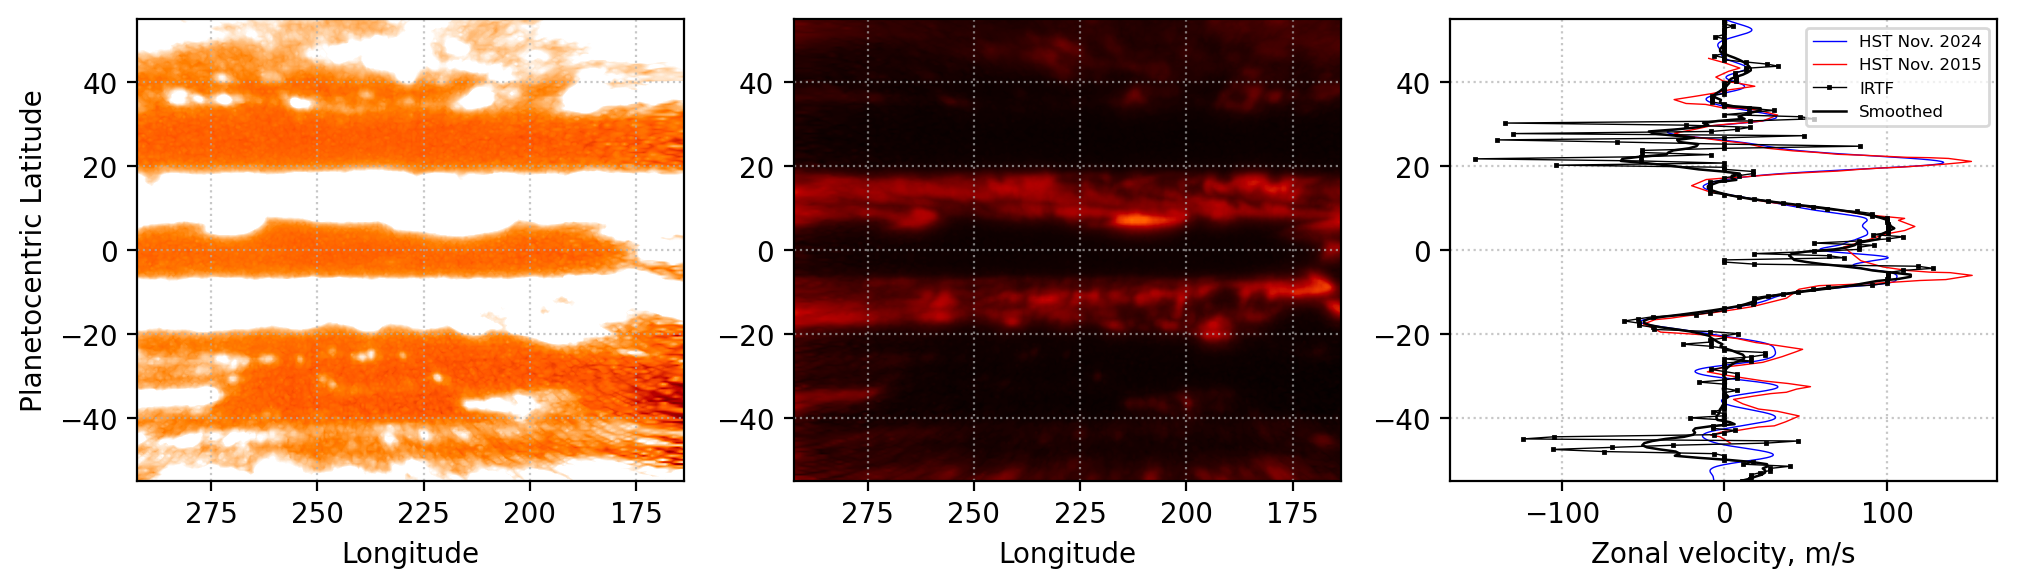

In [12]:
%matplotlib inline

colo = 'gist_heat'
# maps where things are defined...useful for analysis
heatmap1 = shifted_f1[:, margin_applied_in_func_shifted.astype(bool)]
heatmap2 = shifted_f2[:, margin_applied_in_func_shifted.astype(bool)]
plot1_upp, plot1_low = np.nanmax(heatmap1)/2.5e3, np.nanmin(heatmap1)
plot2_upp, plot2_low = np.nanmax(heatmap2)/7.e2, np.nanmin(heatmap2)
print(plot1_upp, plot1_low,
        plot2_upp, plot2_low)
plot1_range, plot2_range = np.linspace(plot1_low, plot1_upp, 256), np.linspace(plot2_low, plot2_upp, 256)

fig, axs = plt.subplots(
nrows=1, ncols=3, figsize=(12, 3), dpi=200)


axs[0].contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap1, plot1_range, cmap=colo, alpha=1)

axs[1].contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap2, plot2_range, cmap=colo)
# axs[1].hlines(-7, 50, 100, ls='dashed', color='w', lw=0.75) 
axs[0].grid(True, 'both', ls=':', alpha=0.7), axs[1].grid(True, 'both', ls=':', alpha=0.7)
axs[0].set_ylim(-y_lim_range, y_lim_range), axs[1].set_ylim(-y_lim_range, y_lim_range)
axs[0].invert_xaxis(), axs[1].invert_xaxis()

# axs[2].plot(hst_wind_1D['x'], hst_wind_1D['y'], color='b', lw=0.5, label='HST 2015')
axs[2].plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.5, label='HST Nov. 2024')
axs[2].plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.5, label='HST Nov. 2015')
axs[2].plot(zwp_5microns, lat_array_use, marker='s', ms=1, color='k', lw=0.5, label='IRTF')
axs[2].plot(smooth_zwp_5microns, lat_array_use, color='k', lw=0.9, label='Smoothed')
axs[2].set_xlabel('Zonal velocity, m/s')
# plt.xlim(-1000, 1000)
axs[2].set_ylim(-y_lim_range, y_lim_range)
axs[2].grid(True, 'both', ls=':', alpha=0.7)
axs[2].legend(loc='upper right', framealpha=0.75, fontsize=6)



axs[0].set_ylabel('Planetocentric Latitude')
axs[0].set_xlabel('Longitude'), axs[1].set_xlabel('Longitude')



plt.show()

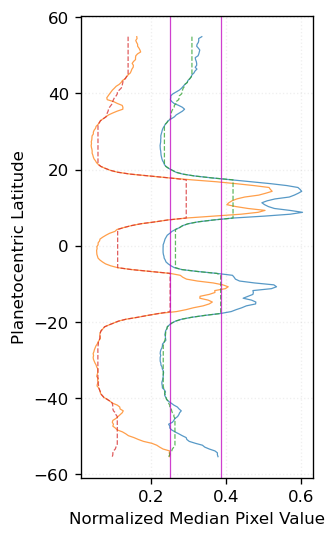

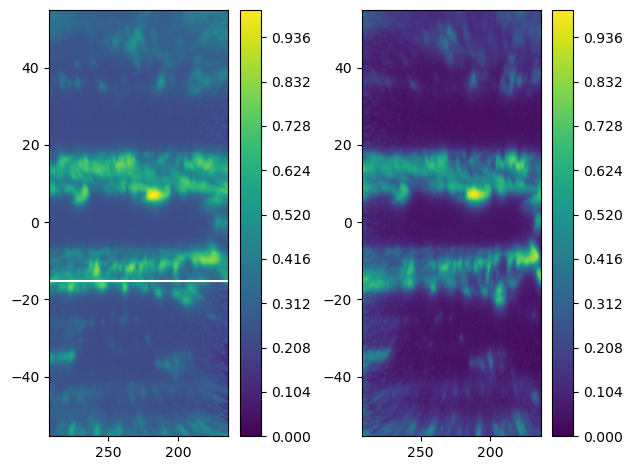

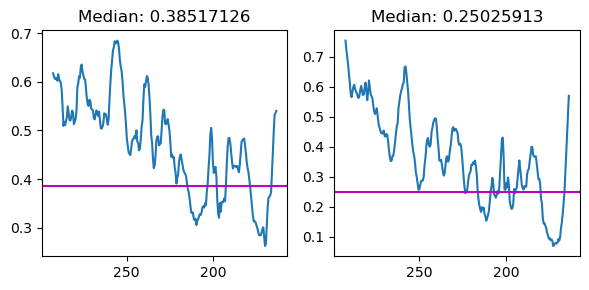

0.0 0.17148875


In [13]:
norm_heatmap_1 = (heatmap1[lat_delta_indices[0]:lat_delta_indices[1], :] - np.nanmin(heatmap1[lat_delta_indices[0]:lat_delta_indices[1], :])) / (np.nanmax(heatmap1[lat_delta_indices[0]:lat_delta_indices[1], :]) - np.nanmin(heatmap1[lat_delta_indices[0]:lat_delta_indices[1], :]))
norm_heatmap_2 = (heatmap2[lat_delta_indices[0]:lat_delta_indices[1], :] - np.nanmin(heatmap2[lat_delta_indices[0]:lat_delta_indices[1], :])) / (np.nanmax(heatmap2[lat_delta_indices[0]:lat_delta_indices[1], :]) - np.nanmin(heatmap2[lat_delta_indices[0]:lat_delta_indices[1], :]))

# individual median profile comparison:
median_profile_1 = np.nanmedian(norm_heatmap_1, axis=1)
median_profile_2 = np.nanmedian(norm_heatmap_2, axis=1)
ks = 41
despiked_prof_1 = sp.signal.medfilt(median_profile_1, ks)
despiked_prof_2 = sp.signal.medfilt(median_profile_2, ks)
# norm_median_profile_1 = median_profile_1 / np.nanmax(median_profile_1)
# norm_median_profile_2 = median_profile_2 / np.nanmax(median_profile_2)
max_of_above = np.maximum(median_profile_1, median_profile_2)


# joint median profile comparison:
# median_profile_1 = np.nanmedian(heatmap1[lat_delta_indices[0]:lat_delta_indices[1], :], axis=1)
# median_profile_2 = np.nanmedian(heatmap2[lat_delta_indices[0]:lat_delta_indices[1], :], axis=1)
# norm_median_profile_1 = median_profile_1 / np.nanmax(median_profile_1)
# norm_median_profile_2 = median_profile_2 / np.nanmax(median_profile_2)
# max_of_above = np.maximum(norm_median_profile_1, norm_median_profile_2)


test_lat_ind = 80
%matplotlib inline
plt.figure(figsize=(2.5, 5), dpi=120)
plt.plot(median_profile_1, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], lw=0.75, alpha=0.75)
plt.plot(median_profile_2, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], lw=0.75, alpha=0.75)
plt.plot(despiked_prof_1, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], ls='dashed', lw=0.75, alpha=0.75)
plt.plot(despiked_prof_2, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], ls='dashed', lw=0.75, alpha=0.75)
# plt.plot(max_of_above, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], lw=0.75, c='k', alpha=0.75)
plt.axvline(despiked_prof_1[test_lat_ind], lw=0.75, c='m', alpha=0.75)
plt.axvline(despiked_prof_2[test_lat_ind], lw=0.75, c='m', alpha=0.75)
plt.grid(True, 'both', ls=':', alpha=0.2)
plt.xlabel('Normalized Median Pixel Value'), plt.ylabel('Planetocentric Latitude')

plt.figure()
plt.subplot(121)
plt.contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], norm_heatmap_1, 256)
plt.axhline(lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]][test_lat_ind], color='w')
plt.gca().invert_xaxis()
plt.colorbar()
plt.subplot(122)
plt.contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]], norm_heatmap_2, 256)#, np.linspace(0.3, 0.4, 8))
plt.gca().invert_xaxis()
plt.colorbar()
plt.tight_layout()


plt.figure(figsize=(6, 3))
plt.subplot(121)
plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], norm_heatmap_1[test_lat_ind, :])
plt.axhline(despiked_prof_1[test_lat_ind], color='m')
plt.gca().invert_xaxis()
plt.title('Median: '+ str(despiked_prof_1[test_lat_ind]))
plt.subplot(122)
plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], norm_heatmap_2[test_lat_ind, :])
plt.axhline(despiked_prof_2[test_lat_ind], color='m')
plt.gca().invert_xaxis()
plt.title('Median: '+ str(despiked_prof_2[test_lat_ind]))
plt.tight_layout()
plt.show()

print(np.min(norm_heatmap_2), np.mean(norm_heatmap_2))

/var/folders/xh/s9lkw5113q98j632zllsplyr0000gq/T/ipykernel_90927/2187500243.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


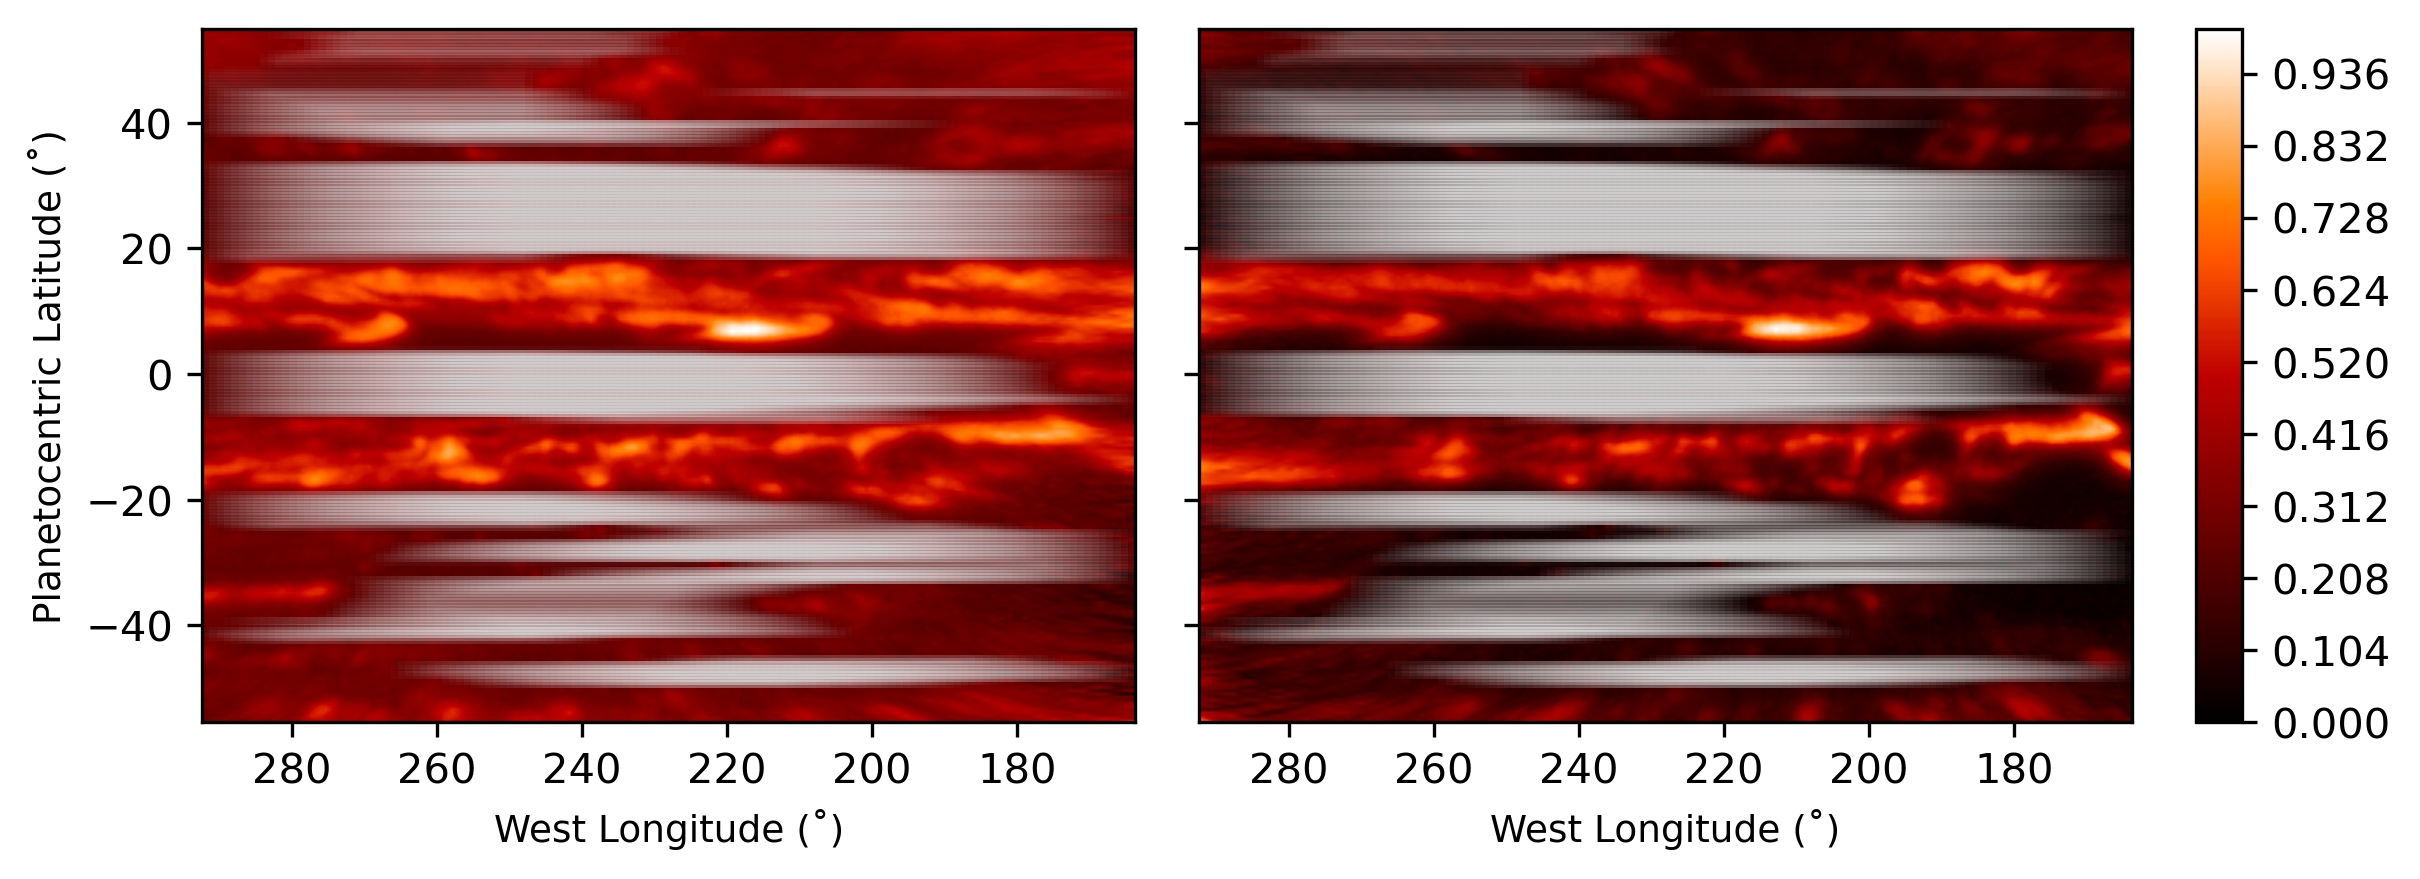

In [28]:
sliding_window_len_in_pixels = int(np.ceil(window_length / (abs(long_array_use[150] - long_array_use[149]))))  

# need to do this stupid thing because colorbars can be dumb...
from matplotlib.gridspec import GridSpec

%matplotlib inline
fig = plt.figure(figsize=(8, 3), dpi=300)
gs = GridSpec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.05],  # last column = colorbar
    wspace=0.1
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

im = ax0.contourf(
    long_array_use[margin_applied_in_func_shifted.astype(bool)],
    lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]],
    norm_heatmap_1,
    256,
    cmap=colo
)

im2 = ax1.contourf(
    long_array_use[margin_applied_in_func_shifted.astype(bool)],
    lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]],
    norm_heatmap_2,
    256,
    cmap=colo
)

reff_index = int(stagger_bool[1, 0, 0])
for l in range(len(lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]])):
    for s in range(stagger_bool[0, ...].shape[-1]):
        if stagger_bool[0, l, s] == 0:
            y = lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]][l]
            x0 = long_array_use[margin_applied_in_func_shifted.astype(bool)][int(stagger_bool[1, l, s] - reff_index)]
            x1 = long_array_use[margin_applied_in_func_shifted.astype(bool)][int(stagger_bool[1, l, s] - reff_index + sliding_window_len_in_pixels - 1)]
            ax0.hlines(y, x0, x1, colors='w', alpha=0.02, lw=2.0)
            ax1.hlines(y, x0, x1, colors='w', alpha=0.02, lw=2.0)

fs = '9'
ax0.set_ylabel('Planetocentric Latitude (˚)', fontsize=fs)
ax0.set_xlabel('West Longitude (˚)', fontsize=fs), ax1.set_xlabel('West Longitude (˚)', fontsize=fs)
ax0.invert_xaxis(), ax1.invert_xaxis()

ax1.tick_params(labelleft=False)
# fig.subplots_adjust(left=0.12
fig.subplots_adjust(
    left=0.10,    # just enough to clear y tick labels
    right=0.95,   # keep colorbar safe
    top=0.92,     # remove top whitespace
    bottom=0.15   # leave room for x labels
)
fig.colorbar(im, cax=cax)
fig.tight_layout()
plt.show()


In [15]:
print(sliding_window_len_in_pixels, long_array_use[margin_applied_in_func_shifted.astype(bool)].shape, lat_array_use[lat_delta_indices[0]:lat_delta_indices[1]].shape, stagger_bool[0, ...].shape)

print(heatmap2[lat_delta_indices[0]:lat_delta_indices[1], :].shape, long_array_use[margin_applied_in_func_shifted.astype(bool)].shape, long_array_use.shape, stagger_bool[1, :, -1])

90 (258,) (221,) (221, 85)
(221, 258) (258,) (720,) [303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303. 303.
 303. 303. 303. 303. 303.

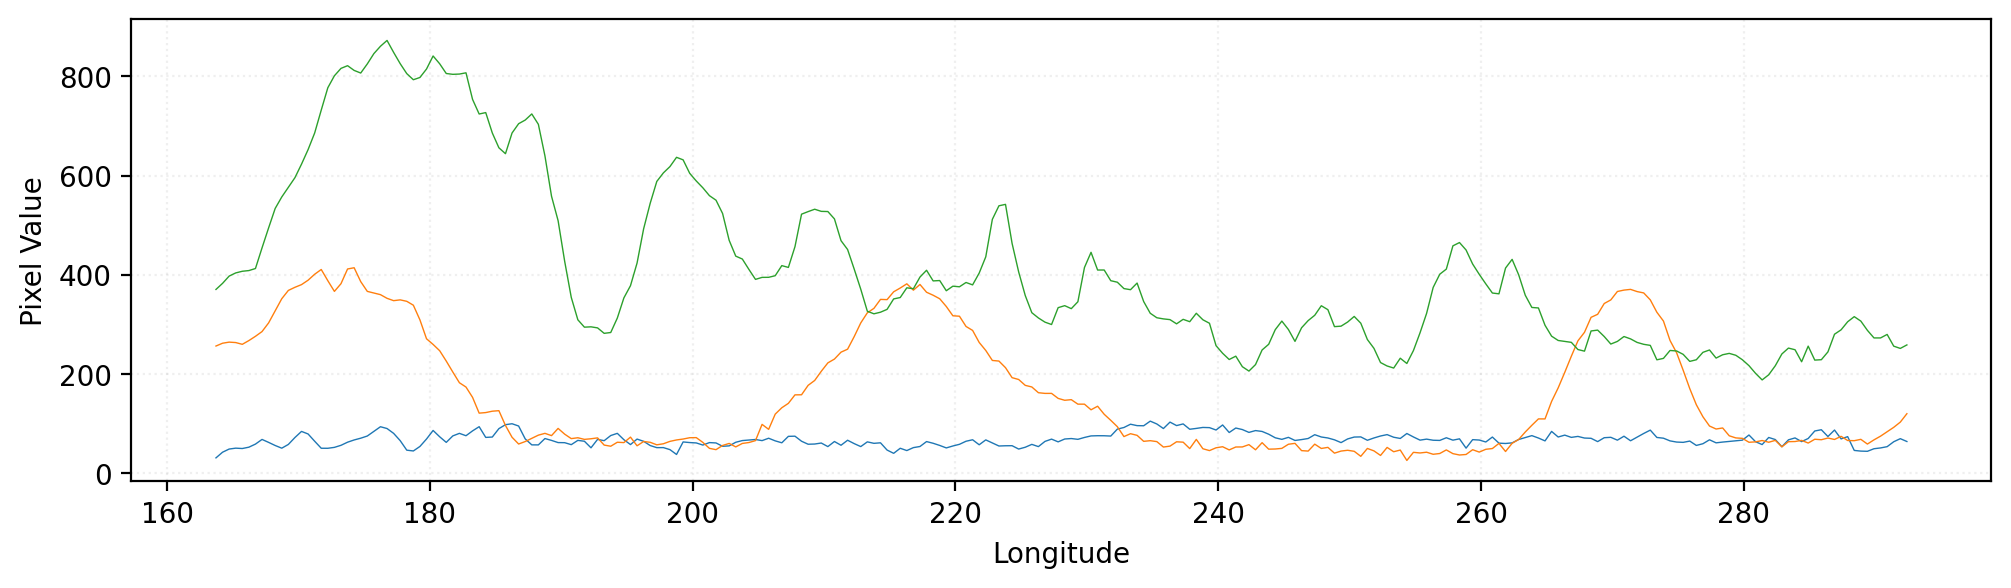

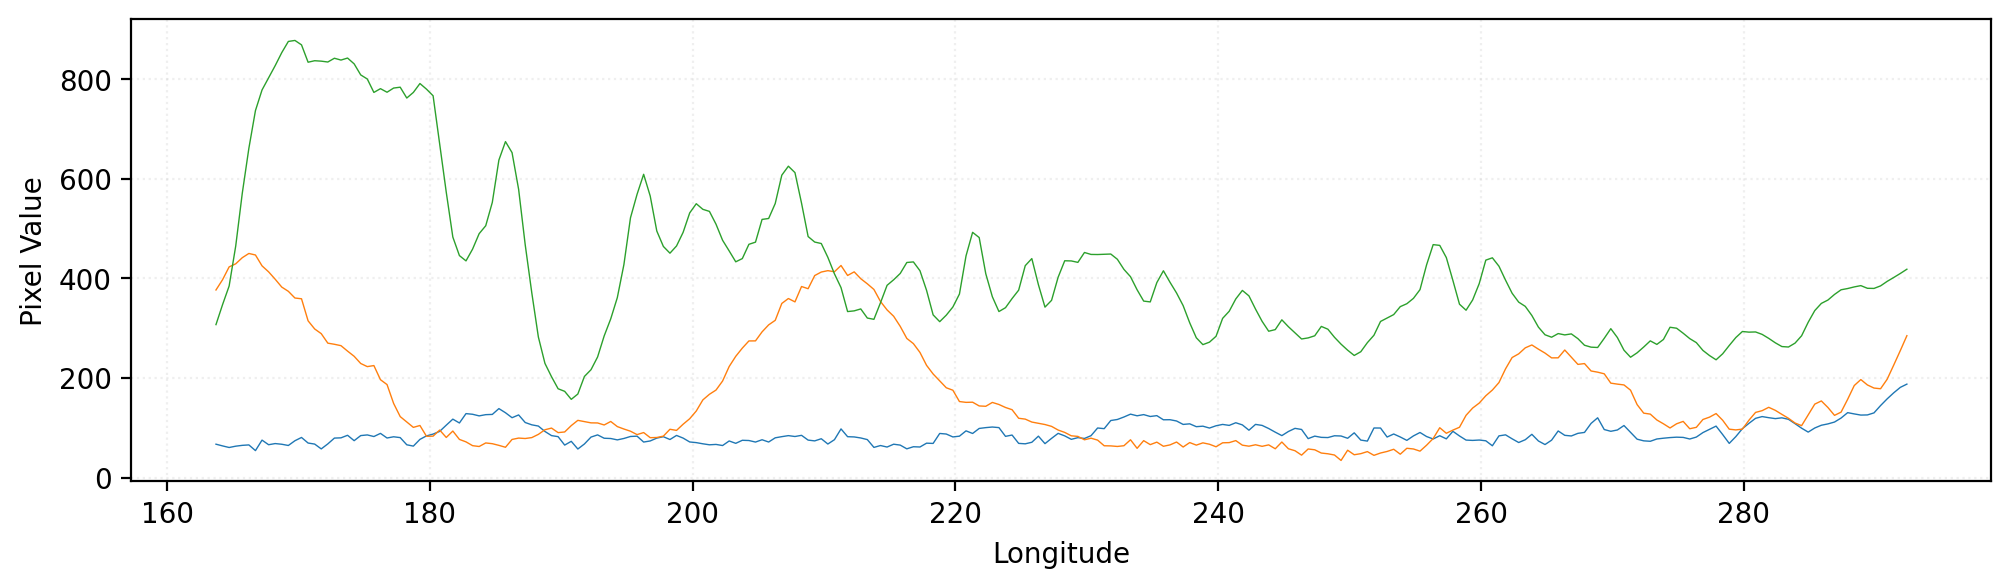

In [16]:


sample_lat_ind, sample_lat = ZWP_Class.closestIndex2Lat(lat_array_use, 20)
sample_lat_ind1, sample_lat1 = ZWP_Class.closestIndex2Lat(lat_array_use, 5)
sample_lat_ind2, sample_lat2 = ZWP_Class.closestIndex2Lat(lat_array_use, -10)
sample_indices = [sample_lat_ind, sample_lat_ind1, sample_lat_ind2]

test_signals = np.empty((len(sample_indices), len(heatmap1[0, :])))

fig, axs = plt.subplots(
nrows=1, ncols=1, figsize=(12, 3), dpi=200)

for i, ival, in enumerate(sample_indices):
        axs.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], heatmap1[ival, :], lw=0.5, alpha=1)
        test_signals[i, :] = heatmap1[ival, :]
axs.grid(True, 'both', ls=':', alpha=0.2)
axs.set_xlabel('Longitude'), axs.set_ylabel('Pixel Value')

fig, axs = plt.subplots(
nrows=1, ncols=1, figsize=(12, 3), dpi=200)
for i, ival, in enumerate(sample_indices):
        axs.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], heatmap2[ival, :], lw=0.5, alpha=1)
axs.grid(True, 'both', ls=':', alpha=0.2)
axs.set_xlabel('Longitude'), axs.set_ylabel('Pixel Value')
plt.show()



In [17]:
# lags = np.arange(-len(shifted_f1_valid) + 1, len(shifted_f2_valid))
        
#                 # Limit the lag range using the physical limit argument
#                 lag_limit_indices = (lags >= -max_lag) & (lags <= max_lag)
#                 corr_limited      = corr[lag_limit_indices]
#                 lags_limited      = lags[lag_limit_indices]

lag_test = np.arange(-10 + 1, 10)
print(lag_test)
print((lag_test >= -4) & (lag_test <= 4))
print(lag_test[(lag_test >= -4) & (lag_test <= 4)])

[-9 -8 -7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8  9]
[False False False False False  True  True  True  True  True  True  True
  True  True False False False False False]
[-4 -3 -2 -1  0  1  2  3  4]


In [18]:
import numpy as np
from scipy import fftpack, ndimage, stats, signal

def detrend_ignore_nan(x):
    x = np.asarray(x, float)
    mask = ~np.isnan(x)
    if mask.sum() < 2:
        return x  # not enough points to detrend; return as-is
    # detrend valid part
    x_valid = signal.detrend(x[mask], type='linear')
    out = x.copy()
    out[mask] = x_valid
    return out

def spectral_entropy_1d(x, eps=1e-12):
    # power spectrum (one-sided)
    X = np.abs(fftpack.fft(x))**2
    X = X[:len(X)//2]
    P = X / (X.sum() + eps)
    H = -np.sum(P * np.log(P + eps))
    # normalize entropy to [0,1] by dividing by log(N)
    return H / np.log(len(P) + eps)

def hf_power_fraction(x, cutoff_frac=0.5):
    # fraction of power above cutoff_frac * Nyquist (0..1)
    N = len(x)
    X = np.abs(fftpack.fft(x))**2
    Xh = X[:N//2]
    cutoff_idx = int(np.floor(cutoff_frac * len(Xh)))
    if cutoff_idx < 1:
        return 0.0
    return Xh[cutoff_idx:].sum() / (Xh.sum() + 1e-12)

def laplacian_energy(x):
    # second difference energy
    d2 = np.diff(x, n=2)
    return np.mean(d2**2)

def total_variation(x):
    return np.mean(np.abs(np.diff(x)))

def mad(x):
    return np.median(np.abs(x - np.median(x)))

def robust_scale_norm(arr):
    # map arr to roughly 0..1 using median/IQR then sigmoid
    med = np.median(arr)
    q1, q3 = np.percentile(arr, [25,75])
    iqr = max(q3 - q1, 1e-12)
    z = (arr - med) / iqr
    # use a sigmoid to compress
    return 1.0 / (1.0 + np.exp(-z))

def irregularity_scores(image, smooth_sigmas=(0.0, 1.0, 3.0), hf_cutoff_frac=0.4, lat_smooth_sigma=1.0):
    """
    image : 2D numpy array of shape (n_lat, n_lon)
    smooth_sigmas : sequence of gaussian sigmas to try (multi-scale)
    returns: score vector length n_lat (0..1)
    """
    n_lat, n_lon = image.shape
    # store metrics per-latitude
    m_std = np.zeros(n_lat)
    m_mad = np.zeros(n_lat)
    m_tv = np.zeros(n_lat)
    m_lap_ms = np.zeros(n_lat)
    m_hf = np.zeros(n_lat)
    m_kurt = np.zeros(n_lat)
    m_peakcount = np.zeros(n_lat)

    for i in range(n_lat):
        row = image[i, :].astype(float)
        # baseline detrend (optional) to remove large-scale gradient:
        # row_d = signal.detrend(row, type='linear')
        row_d = detrend_ignore_nan(row)

        # simple metrics:
        m_std[i] = np.std(row_d)
        m_mad[i] = mad(row_d)
        m_tv[i] = total_variation(row_d)
        m_kurt[i] = stats.kurtosis(row_d, fisher=True, bias=False)  # Fisher => 0 for Gaussian

        # peak count as simple heuristic
        peaks, props = signal.find_peaks(row_d, height=np.std(row_d)*0.5, distance=max(1, n_lon//50))
        m_peakcount[i] = len(peaks)

        # laplacian energy at multiple scales (to capture narrow and broad)
        lap_vals = []
        for sigma in smooth_sigmas:
            if sigma > 0.0:
                r_s = ndimage.gaussian_filter1d(row_d, sigma=sigma, mode='reflect')
            else:
                r_s = row_d
            lap_vals.append(laplacian_energy(r_s))
        m_lap_ms[i] = np.max(lap_vals)  # max across scales

        # HF power fraction
        m_hf[i] = hf_power_fraction(row_d, cutoff_frac=hf_cutoff_frac)

    # Normalize each metric robustly to 0..1
    n_std = robust_scale_norm(m_std)
    n_mad = robust_scale_norm(m_mad)
    n_tv = robust_scale_norm(m_tv)
    n_lap = robust_scale_norm(m_lap_ms)
    n_hf = robust_scale_norm(m_hf)
    # kurtosis can be negative; map via absolute then norm
    n_kurt = robust_scale_norm(np.abs(m_kurt))
    n_peaks = robust_scale_norm(m_peakcount)

    # Combine: give more weight to metrics that detect spikes (lap, tv, hf, kurt)
    weights = {
        'std': 0.15,
        'mad': 0.10,
        'tv': 0.15,
        'lap': 0.25,
        'hf': 0.2,
        'kurt': 0.1,
        'peaks': 0.05
    }
    # compute weighted sum
    combined = (weights['std'] * n_std +
                weights['mad'] * n_mad +
                weights['tv'] * n_tv +
                weights['lap'] * n_lap +
                weights['hf'] * n_hf +
                weights['kurt'] * n_kurt +
                weights['peaks'] * n_peaks)

    # optional smooth across latitudes to reduce single-lat noise
    if lat_smooth_sigma > 0:
        combined = ndimage.gaussian_filter1d(combined, sigma=lat_smooth_sigma, mode='reflect')

    # clip to 0..1
    combined = np.clip(combined, 0.0, 1.0)
    return combined

# Example usage:
# scores = irregularity_scores(my_2d_ir_image)
# now scores.shape == (n_lat,)


In [19]:
scores = irregularity_scores(heatmap1[:-50, :])
scores2 = irregularity_scores(heatmap2[:-50, :])
print(scores.shape, scores2.shape, heatmap1[:-50, :].shape)
print(scores)

(310,) (310,) (310, 258)
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan n

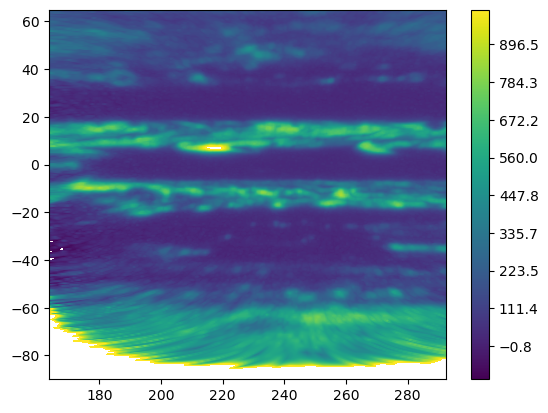

In [20]:
plt.contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use[:-50], heatmap1[:-50, :], np.linspace(-1e2, 1e3, 256))
plt.colorbar()
plt.show()

In [21]:
print(shifted_f1.shape, heatmap1.shape, np.nanmax(shifted_f1), np.nanmin(shifted_f1), np.nanmax(heatmap1), np.nanmax(heatmap1))

(360, 720) (360, 258) 634933.56 -27483.04 423664.4 423664.4


Original, Detrended:
spectral_entropy_1d:  0.031468851769147786 0.6864196778427745
hf_power_fraction:  0.00137417544271886 0.07536148551976894
laplacian_energy:  147.26901164182198 147.26901164182195
total_variation:  6.429617633151637 6.42895655694192
mad:  7.139867782592773 7.24342274966132
kurtosis:  0.22296669407981495 0.3170691664473999

spectral_entropy_1d:  0.1899361192218764 0.3604761901131806
hf_power_fraction:  0.00035843018843148257 0.0011537425815249256
laplacian_energy:  195.07854185674702 195.078541856747
total_variation:  10.574093221226555 10.612517478958102
mad:  46.295888900756836 66.38318321058317
kurtosis:  -0.97519920441461 -0.616570474535898

spectral_entropy_1d:  0.09133363152858599 0.5364476361250798
hf_power_fraction:  0.00011336938895979828 0.009541431500059034
laplacian_energy:  525.6594691935898 525.6594691935895
total_variation:  19.50864169940874 19.52144764600967
mad:  95.34986877441406 71.87798743399298
kurtosis:  0.16237130144033873 -0.05735042795300815

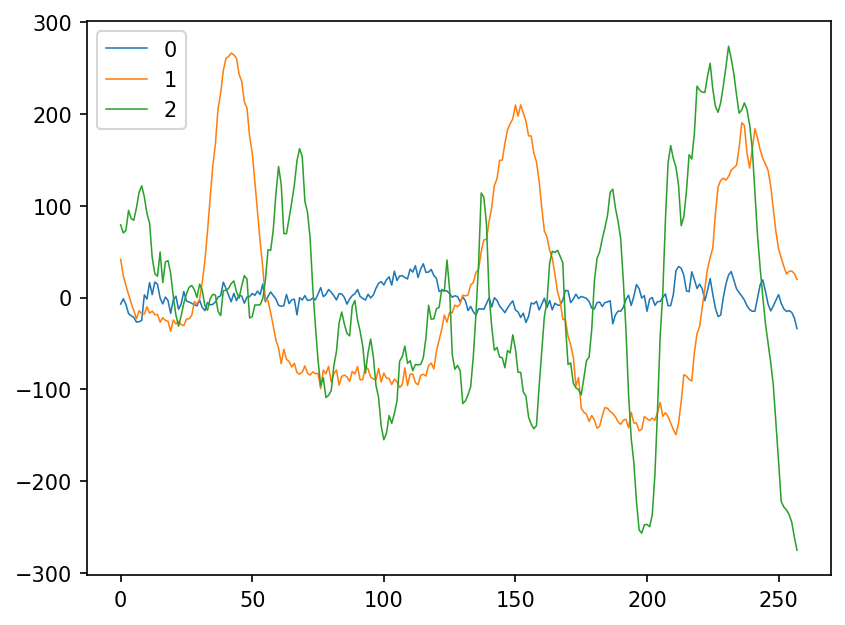

In [22]:
# print(spectral_entropy_1d(heatmap1[ival, :]))
# print(hf_power_fraction(heatmap1[ival, :]))
# print(laplacian_energy(heatmap1[ival, :]))
# print(total_variation(heatmap1[ival, :]))
# print(mad(heatmap1[ival, :]))

print("Original, Detrended:")
plt.figure(dpi=150)
# for i in range(len(test_signals[:, 0])):
#     plt.plot(test_signals[i, :], lw=0.75)
for i in range(len(test_signals[:, 0])):
    plt.plot(detrend_ignore_nan(test_signals[i, :]), lw=0.75, label=str(i))
    # plt.plot(detrend_ignore_nan(test_signals[i, :]), lw=0.75, label=str(i))
    print("spectral_entropy_1d: ", spectral_entropy_1d(test_signals[i, :]), spectral_entropy_1d(detrend_ignore_nan(test_signals[i, :])))
    print("hf_power_fraction: ", hf_power_fraction(test_signals[i, :]), hf_power_fraction(detrend_ignore_nan(test_signals[i, :])))
    print("laplacian_energy: ", laplacian_energy(test_signals[i, :]), laplacian_energy(detrend_ignore_nan(test_signals[i, :])))
    print("total_variation: ", total_variation(test_signals[i, :]), total_variation(detrend_ignore_nan(test_signals[i, :])))
    print("mad: ", mad(test_signals[i, :]), mad(detrend_ignore_nan(test_signals[i, :])))
    print("kurtosis: ", stats.kurtosis(test_signals[i, :], fisher=True, bias=False), stats.kurtosis(detrend_ignore_nan(test_signals[i, :]), fisher=True, bias=False))
    print()
plt.legend()
# test_i = 1
# plt.plot(test_signals[test_i, :], lw=0.75)
# plt.plot(detrend_ignore_nan(test_signals[test_i, :]), lw=0.75, ls=':')
# plt.plot(detrend_ignore_nan(test_signals[test_i, :]), lw=0.75, ls=':')

# print("spectral_entropy_1d: ", spectral_entropy_1d(test_signals[test_i, :]), spectral_entropy_1d(detrend_ignore_nan(test_signals[test_i, :])))
# print("hf_power_fraction: ", hf_power_fraction(test_signals[test_i, :]), hf_power_fraction(detrend_ignore_nan(test_signals[test_i, :])))
# print("laplacian_energy: ", laplacian_energy(test_signals[test_i, :]), laplacian_energy(detrend_ignore_nan(test_signals[test_i, :])))
# print("total_variation: ", total_variation(test_signals[test_i, :]), total_variation(detrend_ignore_nan(test_signals[test_i, :])))
# print("mad: ", mad(test_signals[test_i, :]), mad(detrend_ignore_nan(test_signals[test_i, :])))
plt.show()

Metrics for selection... (use smooth signal)
Index:  0
Prominence:  15.6817689491245 Val. Range:  60.416737220175506
MAX:  98.87244856064153 MEDIAN:  66.98809242565596 STD:  11.297390520395082
Index:  1
Prominence:  252.9549174541321 Val. Range:  356.3128352116204
MAX:  395.36180268037833 MEDIAN:  94.28531607613772 STD:  118.38755971688578
Index:  2
Prominence:  223.6893243773742 Val. Range:  647.4816692186907
MAX:  851.3366012772543 MEDIAN:  372.2907061460247 STD:  174.43059509289506


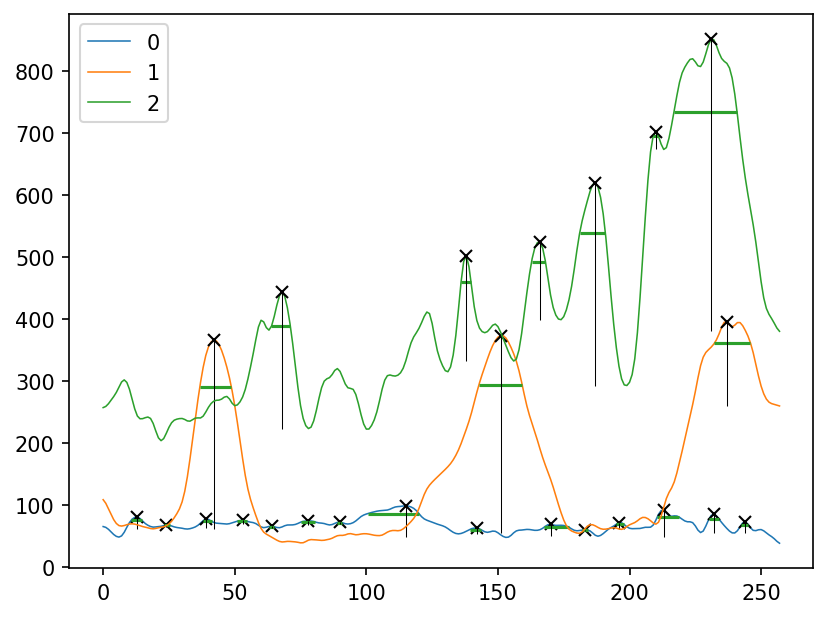

In [23]:
std_width_scale = 2.5

%matplotlib inline
plt.figure(dpi=150)
print('Metrics for selection... (use smooth signal)')
for i in range(len(test_signals[:, 0])):
    detrended = (test_signals[i, :]) # using the "trended" version can work better sometimes... remove use of detrend_ignore_nan
    detrended = ndimage.gaussian_filter1d(detrended, sigma=1.5, mode='reflect')
    plt.plot(detrended, lw=0.75, label=str(i))
    
    conditional_arr = detrended[(detrended - np.nanmedian(detrended)) >= np.nanstd(detrended)*1.5]
    # #peaks = np.where(np.isin(detrended, conditional_arr))[0]
    peaks, props = signal.find_peaks(detrended, height=(np.std(detrended))*std_width_scale, distance=max(1, len(detrended)//25))
    prominences = signal.peak_prominences(detrended, peaks)[0]
    contour_heights = detrended[peaks] - prominences
    results_half = signal.peak_widths(detrended, peaks, rel_height=0.25)
    plt.plot(peaks, detrended[peaks], 'x', color='k')
    plt.hlines(*results_half[1:], color="C2")
    plt.vlines(x=peaks, ymin=contour_heights, ymax=detrended[peaks], lw=0.5, color='k')
    
    print('Index: ', i)
    print('Prominence: ', np.mean(detrended[peaks] - contour_heights), 'Val. Range: ', np.max(detrended) - np.min(detrended))
    print('MAX: ', np.max(detrended), 'MEDIAN: ', np.median(detrended), 'STD: ', np.std(detrended))

    # conditional_arr = detrended[(detrended - np.nanmedian(detrended)) >= np.nanstd(detrended)*1.5]
    # print(conditional_arr)
    # #peakind = np.where(np.isin(detrended, conditional_arr))[0]
    # peakind = signal.find_peaks_cwt(detrended, np.arange(1,30), min_snr=5.0)
    # prominences_cwt = signal.peak_prominences(detrended, peakind, wlen=10)[0]
    # contour_heights_cwt = detrended[peakind] - prominences_cwt
    # results_half = signal.peak_widths(detrended, peakind, rel_height=0.5)
    # plt.plot(peakind, detrended[peakind], '+', color='r')
    # plt.hlines(*results_half[1:], color="C2")
    # plt.vlines(x=peakind, ymin=contour_heights_cwt, ymax=detrended[peakind], lw=0.75, ls=':', color='r')

    # print('Index: ', i)
    # print('Prominence: ', np.mean(detrended[peakind] - contour_heights_cwt), 'Val. Range: ', np.max(detrended) - np.min(detrended))
    # print('MAX: ', np.max(detrended), 'MEDIAN: ', np.median(detrended), 'STD: ', np.std(detrended))




plt.legend()
plt.show()

In [24]:
print(peaks, props)

[ 68 138 166 187 210 231] {'peak_heights': array([443.6756938 , 501.71686698, 523.65634416, 619.91702889,
       702.27002122, 851.33660128])}


In [25]:
print(*results_half[1:])

[388.38593604 459.3697906  492.49008464 538.14434181 695.0855931
 733.56282357] [ 63.92936653 135.99049392 162.805087   181.03995354 208.97538914
 216.88064565] [ 71.12889421 139.77378129 168.05953871 190.83637326 211.00084678
 240.87251716]


In [26]:
output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/' + year + '/'
zwp_output_str = cmap_files_paths_list_51[test_i][0].split('/')[4] + '_' + cmap_files_paths_list_51[test_i][0].split('/')[-1].split('.cmap')[0] + '_' + cmap_files_paths_list_51[test_i][1].split('/')[-1].split('.cmap')[0]
# sansa_zwp_output_str = cmap_files_paths_list_51[test_i][0].split('/')[1][:4+3]+'_'+cmap_files_paths_list_51[test_i][0].split('/')[2].split('.')[0]+'_'+cmap_files_paths_list_51[test_i][1].split('/')[2].split('.')[0]
pair_names = [cmap_files_paths_list_51[test_i][0].split('/')[-1], cmap_files_paths_list_51[test_i][1].split('/')[-1]]

print(cmap_files_paths_list_51[test_i])
print(output_path, zwp_output_str)
print(pair_names)
print(date_meta_list[test_i])

['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz', '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz']
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2024/ 2024aug16_jc183201_jc042065
['jc183201.cmap.gz', 'jc042065.cmap.gz']
['2024-08-16T19:50:05.20312', '2024-08-17T14:45:15.22656']


In [27]:
# Testing different R(phi) values:

# plt.figure(dpi=150)
# used_R = R_J*(1 - oblateness*np.sin(lat_array*np.pi/180)**2) / 1e3
# raul_R = R_J * R_J_p / (np.sqrt(R_J**2 * np.sin(lat_array*np.pi/180)**2 + R_J_p**2 * np.cos(lat_array*np.pi/180)**2)) / 1e3
# plt.plot(abs(used_R - raul_R), lat_array)
# # plt.plot(used_R, lat_array)
# # plt.plot(raul_R, lat_array)
# plt.show()